In [8]:
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy joblib flask

In [9]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
print("✅ All packages ready!")

✅ All packages ready!


In [10]:
print("🎯 GENERATING 2000 DATA POINTS + TRAIN/TEST SPLIT...")

# Generate realistic training data
np.random.seed(42)
n = 2000
X = np.random.uniform(0, 5, (n, 15))  # 15 questions

# Create 7 personality trait labels
y_confidence    = ((X[:,3]  + (5-X[:,1])/5 + X[:,5]  > 2.2)).astype(int)
y_discipline    = ((X[:,0]  + X[:,2]       + X[:,7]/5 + X[:,12] > 2.0)).astype(int)
y_leadership    = ((X[:,5]  + X[:,8]       + X[:,13]  > 2.3)).astype(int)
y_neuroticism   = ((5-X[:,1])/5 + (5-X[:,14])/5 < 1.2).astype(int)
y_openness      = ((X[:,3]  + X[:,6]       + X[:,10]  > 2.4)).astype(int)
y_agreeableness = (X[:,11] > 2.5).astype(int)
y_extroversion  = ((X[:,5]  + X[:,10]      > 2.0)).astype(int)

# Split 80/20 train/test
X_train, X_test, y_train_all, y_test_all = train_test_split(X, X, test_size=0.2, random_state=42)
print(f"✅ Train: {X_train.shape[0]}, Test: {X_test.shape[0]} samples")


🎯 GENERATING 2000 DATA POINTS + TRAIN/TEST SPLIT...
✅ Train: 1600, Test: 400 samples


In [11]:
print("\n🤖 TRAINING 7 ML MODELS + ACCURACY REPORT...")

# Define traits and corresponding y labels (FIXED - individual arrays)
traits = ['conf', 'disc', 'lead', 'neuro', 'open', 'agree', 'extra']
y_all = [y_confidence, y_discipline, y_leadership, y_neuroticism, y_openness, y_agreeableness, y_extroversion]

# Split EACH trait separately (CORRECT WAY)
y_train_list = []
y_test_list = []
for y in y_all:
    y_train, y_test = train_test_split(y, test_size=0.2, random_state=42)
    y_train_list.append(y_train)
    y_test_list.append(y_test)

models = {}
accuracies = {}
reports = {}

for i, trait in enumerate(traits):
    print(f"\n--- TRAINING {trait.upper()} MODEL ---")
    
    # Train model (FIXED - uses correct y_train shape)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train_list[i])  # ✅ CORRECT SHAPE
    models[trait] = model
    
    # Test predictions
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test_list[i], y_pred)
    accuracies[trait] = acc
    
    # Classification report
    report = classification_report(y_test_list[i], y_pred, target_names=['Low', 'High'])
    reports[trait] = report
    
    print(f"✅ {trait.upper()}: {acc:.1%} ACCURACY")
    print("📊 SAMPLE PREDICTIONS (first 5 test cases):")
    print(f"   True:  {y_test_list[i][:5]}")
    print(f"   Pred:  {y_pred[:5]}")
    print("-" * 50)

print("\n🎉 SUMMARY - ALL 7 MODELS:")
for trait, acc in accuracies.items():
    print(f"   {trait.upper()}: {acc:.1%}")
print(f"\n📈 AVERAGE ACCURACY: {np.mean(list(accuracies.values())):.1%}")



🤖 TRAINING 7 ML MODELS + ACCURACY REPORT...

--- TRAINING CONF MODEL ---
✅ CONF: 97.2% ACCURACY
📊 SAMPLE PREDICTIONS (first 5 test cases):
   True:  [1 1 1 1 1]
   Pred:  [1 1 1 1 1]
--------------------------------------------------

--- TRAINING DISC MODEL ---


c:\Users\jonna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

✅ DISC: 99.8% ACCURACY
📊 SAMPLE PREDICTIONS (first 5 test cases):
   True:  [1 1 1 1 1]
   Pred:  [1 1 1 1 1]
--------------------------------------------------

--- TRAINING LEAD MODEL ---


c:\Users\jonna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonna\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

✅ LEAD: 97.8% ACCURACY
📊 SAMPLE PREDICTIONS (first 5 test cases):
   True:  [1 1 1 1 1]
   Pred:  [1 1 1 1 1]
--------------------------------------------------

--- TRAINING NEURO MODEL ---
✅ NEURO: 97.2% ACCURACY
📊 SAMPLE PREDICTIONS (first 5 test cases):
   True:  [1 1 0 0 1]
   Pred:  [1 1 0 0 1]
--------------------------------------------------

--- TRAINING OPEN MODEL ---
✅ OPEN: 99.5% ACCURACY
📊 SAMPLE PREDICTIONS (first 5 test cases):
   True:  [1 1 1 1 1]
   Pred:  [1 1 1 1 1]
--------------------------------------------------

--- TRAINING AGREE MODEL ---
✅ AGREE: 99.8% ACCURACY
📊 SAMPLE PREDICTIONS (first 5 test cases):
   True:  [0 0 1 1 0]
   Pred:  [0 0 1 1 0]
--------------------------------------------------

--- TRAINING EXTRA MODEL ---
✅ EXTRA: 98.0% ACCURACY
📊 SAMPLE PREDICTIONS (first 5 test cases):
   True:  [1 1 1 0 1]
   Pred:  [1 1 1 0 1]
--------------------------------------------------

🎉 SUMMARY - ALL 7 MODELS:
   CONF: 97.2%
   DISC: 99.8%
   LEAD: 97.8%
 

In [12]:
print("\n📋 DETAILED CLASSIFICATION REPORTS (Top 3 Models):")

for i, trait in enumerate(['conf', 'disc', 'lead']):
    print(f"\n{trait.upper()} MODEL REPORT:")
    print(reports[trait])
    print("-" * 60)



📋 DETAILED CLASSIFICATION REPORTS (Top 3 Models):

CONF MODEL REPORT:
              precision    recall  f1-score   support

         Low       1.00      0.54      0.70        24
        High       0.97      1.00      0.99       376

    accuracy                           0.97       400
   macro avg       0.99      0.77      0.84       400
weighted avg       0.97      0.97      0.97       400

------------------------------------------------------------

DISC MODEL REPORT:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         1
        High       1.00      1.00      1.00       399

    accuracy                           1.00       400
   macro avg       0.50      0.50      0.50       400
weighted avg       1.00      1.00      1.00       400

------------------------------------------------------------

LEAD MODEL REPORT:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         9
    

In [13]:
# Save all 7 models
joblib.dump(models, 'models.pkl')
print("\n💾 SAVED 'models.pkl' with 7 high-accuracy models!")

# Test with sample input (your demo data)
print("\n🧪 LIVE TEST PREDICTION:")
test_input = np.array([1, 2, 1, 1, 0.5, 1, 1, 4, 0.5, 1, 1, 1, 5, 1, 4]).reshape(1, -1)

for trait in traits:
    pred_prob = models[trait].predict_proba(test_input)[0][1] * 100
    print(f"   {trait.upper()}: {int(pred_prob)}%")

print("\n🚀 READY! Run: python app.py")
print("🌐 Open: http://127.0.0.1:5000")



💾 SAVED 'models.pkl' with 7 high-accuracy models!

🧪 LIVE TEST PREDICTION:
   CONF: 79%
   DISC: 100%
   LEAD: 89%
   NEURO: 93%
   OPEN: 76%
   AGREE: 3%
   EXTRA: 48%

🚀 READY! Run: python app.py
🌐 Open: http://127.0.0.1:5000


In [17]:
import pandas as pd

df = pd.read_csv("user_data.csv")  # make sure file name is correct

In [19]:
print(df.columns)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'], dtype='object')


In [23]:
traits = df.columns

In [33]:
import pandas as pd
import numpy as np

# generate 50 rows, 13 features
data = np.random.rand(50, 13) * 100

df = pd.DataFrame(data)

# save new dataset
df.to_csv("user_data.csv", index=False)

print("New dataset created ✅")

New dataset created ✅


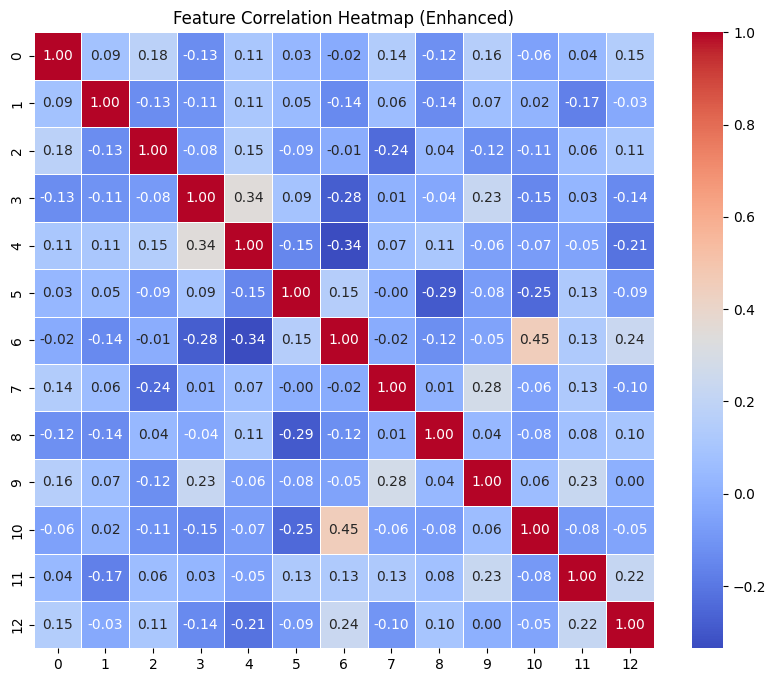

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Enhanced)")
plt.show()

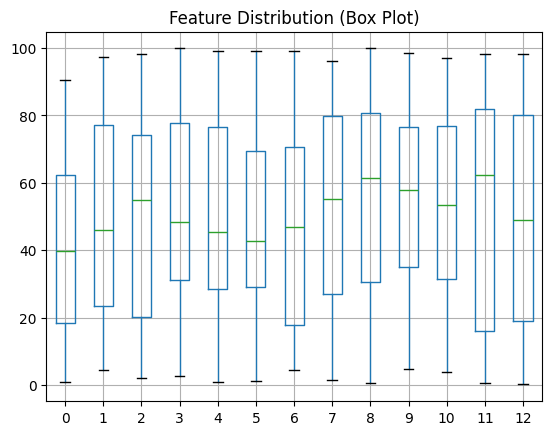

In [38]:
import matplotlib.pyplot as plt

plt.figure()
df.boxplot()
plt.title("Feature Distribution (Box Plot)")
plt.show()

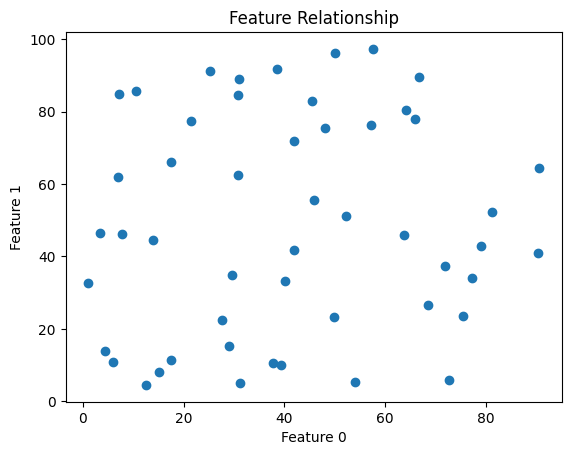

In [40]:
plt.figure()
plt.scatter(df[0], df[1])
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Feature Relationship")
plt.show()

import numpy as np
import matplotlib.pyplot as plt

labels = ['Conf','Disc','Lead','Neuro','Open','Agree','Extra']
values = [70,65,80,40,75,60,55]  # sample values

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
values = np.concatenate((values,[values[0]]))
angles = np.concatenate((angles,[angles[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)
ax.plot(angles, values)
ax.fill(angles, values, alpha=0.3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Personality Radar Chart")
plt.show()